# Identification of Duffing oscillator system

In [2]:
# import all the necessary libraries
import pysindy as ps
from pysindy.feature_library import CustomLibrary
import numpy as np

from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

We consider the following Duffing Oscillator
$$\ddot{x} + c \dot{x} + k x + \alpha x^3 = 0$$

In [3]:
# The Duffing oscillator system
def duffing(t, x, c=0.1, alpha=0.5, k=1):
    return [x[1], 
           -k * x[0] - c * x[1] - alpha * x[0] ** 3]

In [4]:
# generate the data for testing
start = 0
end = 100
step = 0.01
t_span = [start, end]
x0 = [0.3, 0.1]
sol = solve_ivp(duffing, t_span, x0, dense_output=True)
t = np.arange(start, end+step/10, step)
x = sol.sol(t).T

In [5]:
# The feature names of the columns of y
feature_names = ['x1', 'x2']

# Which feature library to use
# Here I'm using a polynomial library that contains all combinations of the columns upto the degree 3
feature_library = ps.PolynomialLibrary(degree=3)


# functions = [lambda x : x, lambda x: x**3]
# function_names = [lambda x : str(x), lambda x: str(x) + "^3"]
# lib_custom = CustomLibrary(library_functions=functions, 
#                            function_names=function_names)
# lib_custom.fit(x)
# lib_custom.transform(x)

# Differentiation method
differentiation_method = ps.FiniteDifference(order=2)

# Optimizer
# opt = ps.SR3(threshold=0.3,thresholder='L0')
opt = ps.STLSQ(threshold=0.05)

# Building the model
model=ps.SINDy(differentiation_method=differentiation_method,
               feature_library = feature_library,
               feature_names=feature_names, 
              optimizer=opt)

# Fitting the model to the training data
model.fit(x,t=t)

# Print the model
model.print()

(x1)' = 1.000 x2
(x2)' = -1.000 x1 + -0.100 x2 + -0.498 x1^3


In [6]:
# Simulate the identified system 
sim = model.simulate(x0,t=t)

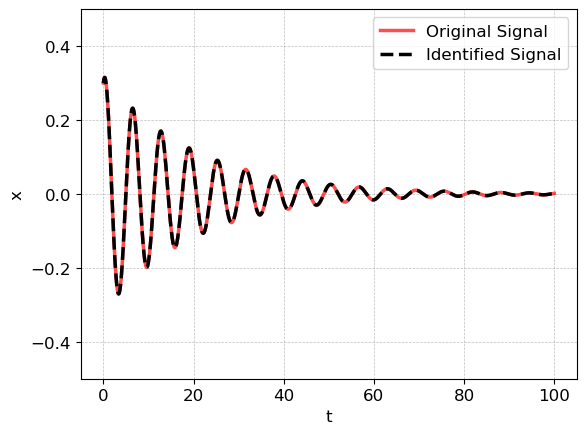

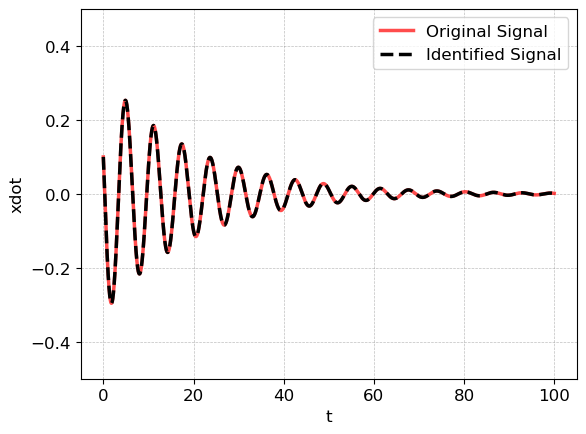

In [7]:
# plot the solution

plt.rcParams.update({'font.size': 12})

# displacement
plt.plot(t,x[:,0],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,0],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x")
plt.legend(loc='upper right')
plt.ylim((-0.5,0.5))
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('disp_duffing.pdf', format='pdf', dpi=300)
plt.show()

# velocity
plt.plot(t,x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,1],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("xdot")
plt.legend()
plt.ylim((-0.5,0.5))
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('vel_duffing.pdf', format='pdf', dpi=300)
plt.show()

# # Error
# plt.plot(t, np.abs(sim[:,0]-x[:,0]))
# plt.xlabel("t")
# plt.ylabel("Error")
# plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
# plt.savefig('error_duffing.pdf', format='pdf', dpi=300)
# plt.show()


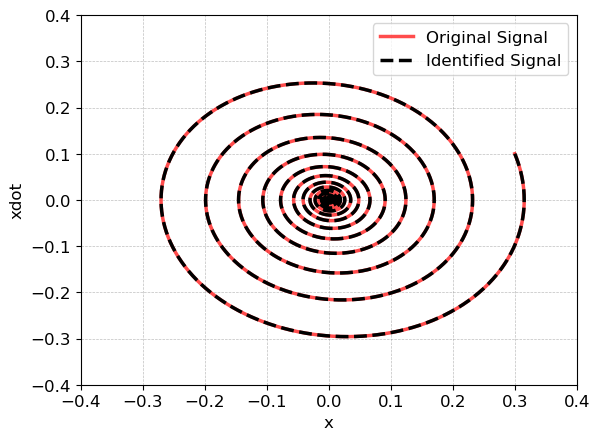

In [8]:
# velocity
plt.plot(x[:,0],x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(sim[:,0],sim[:,1],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("x")
plt.ylabel("xdot")
plt.legend()
plt.xlim((-0.4,0.4))
plt.ylim((-0.4,0.4))
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('pp_duffing.pdf', format='pdf', dpi=300)
plt.show()

In [9]:
print(x)

[[0.3        0.1       ]
 [0.30098381 0.096761  ]
 [0.30193519 0.09351426]
 ...
 [0.00148478 0.00148655]
 [0.00149956 0.00147015]
 [0.00151418 0.00145361]]
